Specifications needed for this galaxy: \
gal = '64.173576_-55.92331' \
maxarea sourcemask=4000 \
compute initial sourcemask before computing initial ellipse fit (find_galaxy to be exact) \
after changes results seem secure and promising

In [2]:
# mind different galaxy
gal = '62.557086_-55.886732'
output_folder = 'output_sota_v6'
filter = 'VIS'

In [3]:
##########################################################################
# Pipeline for SBF amplitude calculation, specifically for Euclid data, 
# based on the code of Lei Titulaer

# Version 2. Implementing unity in geometry
##########################################################################

version = "2.4"
# changes: 
# - improved version aperture model

# - background calculation not disturbed by nans/infs
# - masked objects larger masks
# - ellipse fit smaller step size

# Imports 

import os 
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
from astropy.io import fits
from astropy.wcs import WCS 
from astroscrappy import detect_cosmics

from mgefit.find_galaxy import find_galaxy


import sys
sys.path.append("./functions")

# Own function imports 
from plotting import imdisplay
from extractdata import extractData
from backgroundmodel import mainBackgroundEstimation, sexFieldBackgroundEstimation
from ellipsemodels import MainFitEllipseModel, fitApertureModel
from sourcemasking import maskBackgroundSources, maskCircle, createRequiredVariables
from empiricalpsf import extractPsfSources
from fourierfunctions import calculateSBF, appSBFmagnitude
from librarypsfhubble import calculateLibrarySBF
from sbfuncertainties import sbfMagnitudeAnnuliSigmas

In [7]:
field_path = '{}/{}/{}/psf/field.fits'.format(output_folder,gal,filter)
# return_path = '{}/{}/{}/psf'.format(output_folder,gal,filter)
# extractPSF(field_path, return_path, filter, image_type='stacked')  already computed

psf_path = '{}/{}/{}/psf/stars.psf'.format(output_folder,gal,filter)
psf_data = fits.getdata(psf_path, ext=1,header=False)
psf = psf_data[0][0][0]
psf /= np.sum(psf)

data_path = '{}/{}/{}/gal'.format(output_folder,gal,filter)
file_path = None #'{}/{}/{}/return_files'.format(output_folder,gal,filter)
image_path = None #'{}/{}/{}/images'.format(output_folder,gal,filter)
make_plots=True
plot_plots=True
maxarea_sourcemask=None
background_estimation=True
background=None
sma_rescale=0.8
cosmic_ray_method='astroscrappy'
premstop=False
geometry = None

ellipsefitter='v6'

version 2.4
computing galaxy from output_sota_v6/62.557086_-55.886732/VIS/gal

1. Extracting the data ...


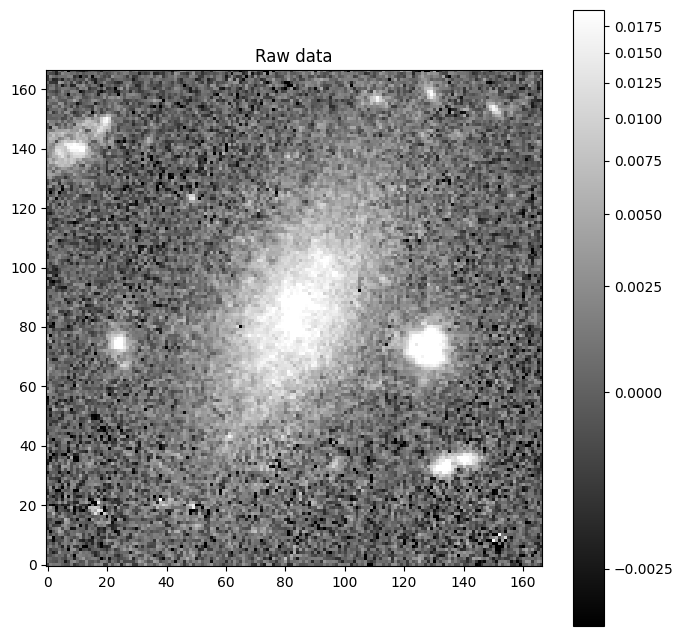


2. Performing sextractor background estimation on field ...


In [8]:
###############
# Main SBF calculation pipeline function
###############

print(f"version {version}")
print(f'computing galaxy from {data_path}')
print("\n1. Extracting the data ...")
plt.close()
data, mask_cr, wcs, mzp = extractData(data_path, file_path=file_path, image_path=image_path, make_plots=make_plots, plot_plots=plot_plots, filter=filter, cosmic_ray_method=cosmic_ray_method)

if field_path != None:
    print("\n2. Performing sextractor background estimation on field ...")
    data, total_bckgr = sexFieldBackgroundEstimation(data,field_path)
    sex_bckgr = 0
else:
    if background_estimation:
        print("\n2. Performing background estimation ...")
        data, total_bckgr, sex_bckgr = mainBackgroundEstimation(data, mask_cr, image_path=image_path, make_plots=make_plots, plot_plots=plot_plots)

    else:
        print("\n2. No background estimation performed ...")
        sex_bckgr = 0
        if background != None:
            total_bckgr = background
            data -= total_bckgr
        else:
            total_bckgr = 0

if file_path != None:
    np.savetxt(file_path + "/background", [total_bckgr, sex_bckgr, mzp])
    np.savetxt(file_path + "/data_background_subtracted", data)


3. Fitting initial aperture ellipse model ...


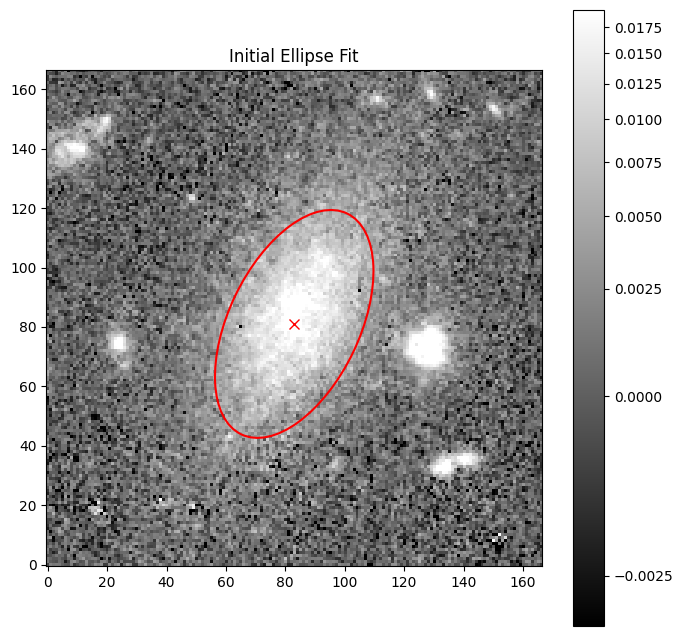

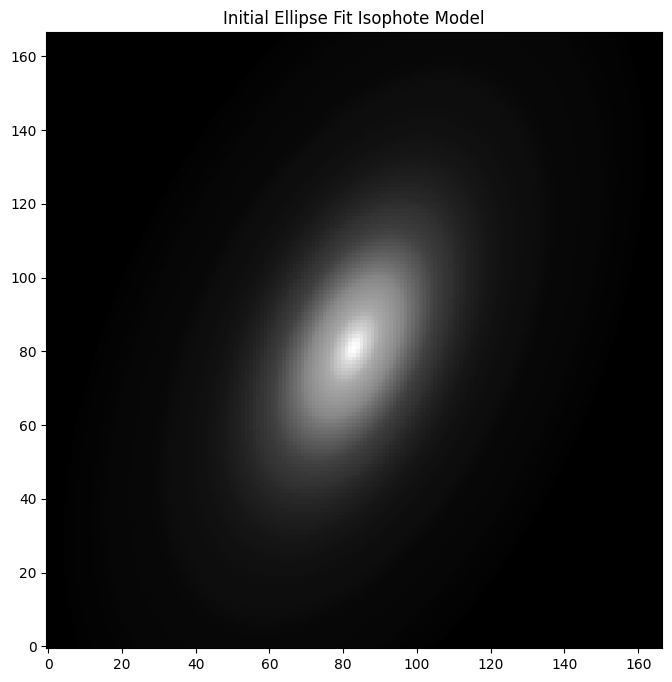

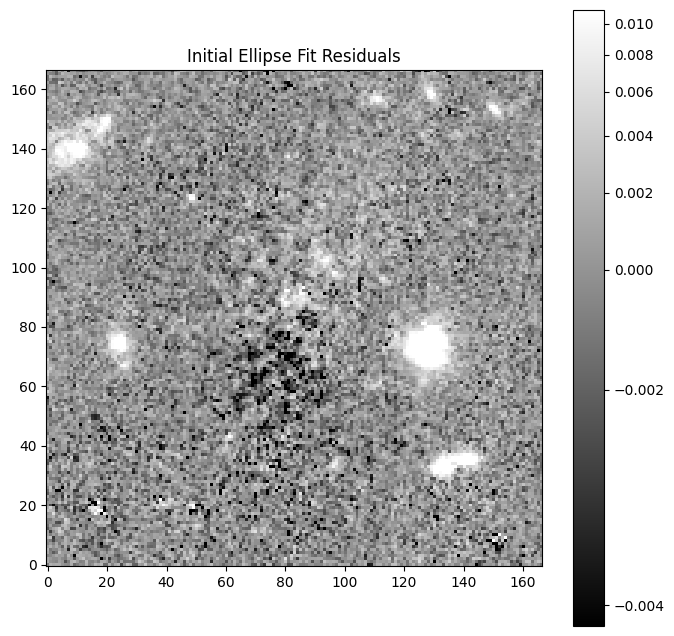


4. Finding initial source mask ...


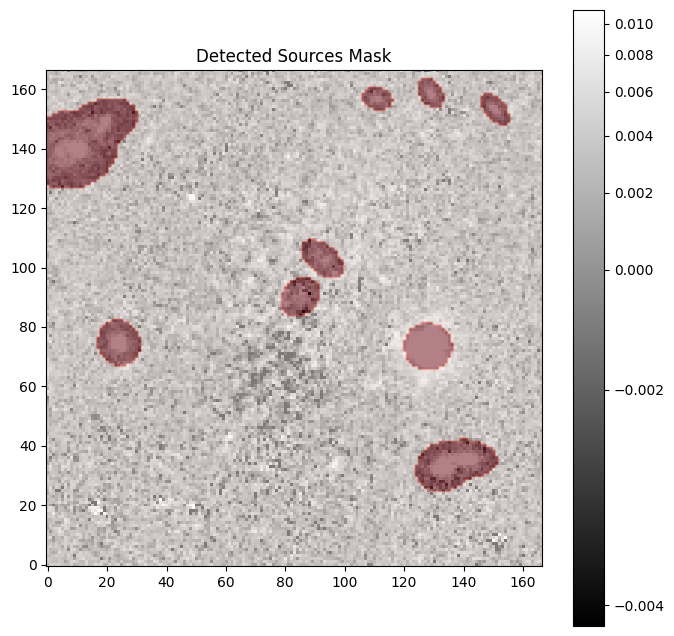


5. Fitting final aperture ellipse model ...


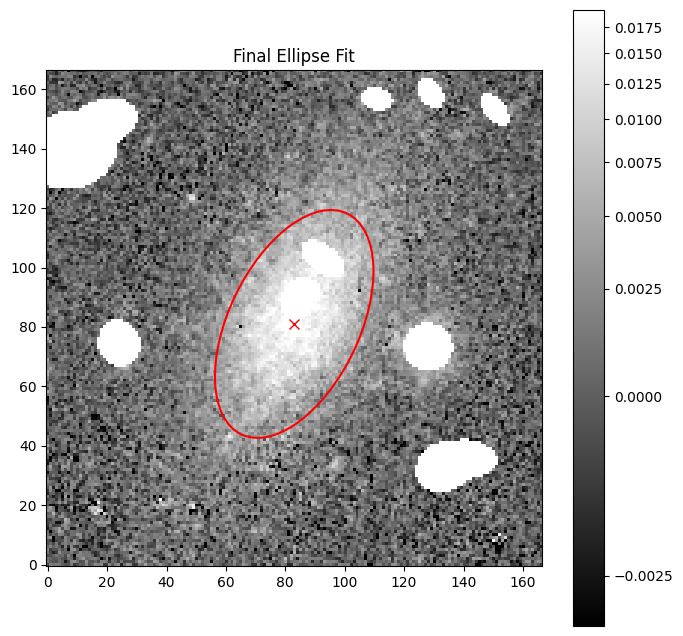

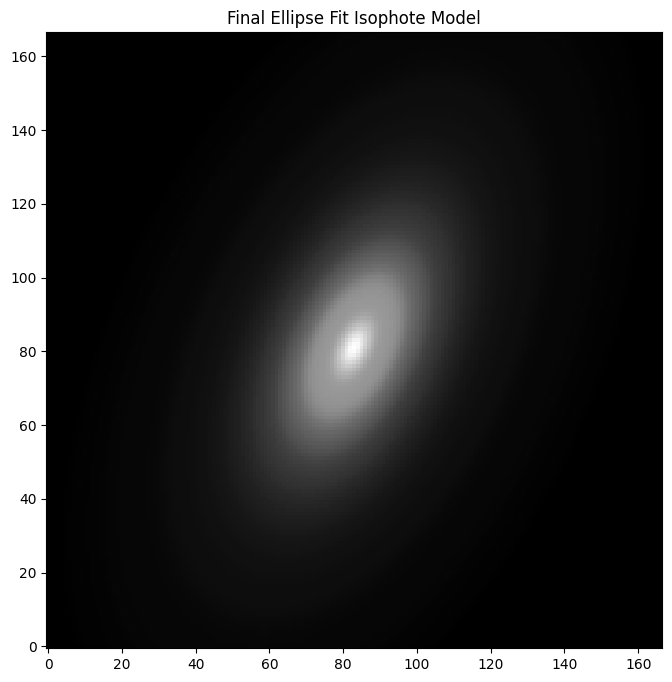

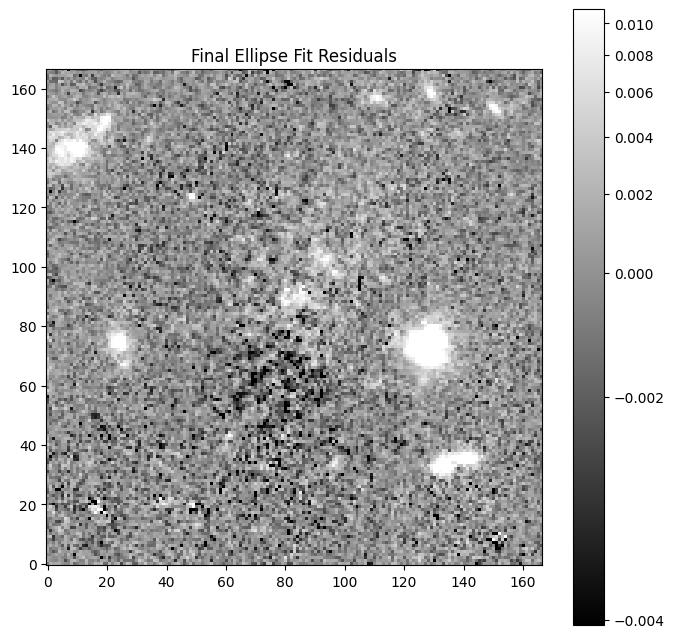

In [16]:
ellipsefitter = 'a1'
print("\n3. Fitting initial aperture ellipse model ...")
residual_basic, model_basic, geometry = fitApertureModel(data, mask_cr=mask_cr, geometry=None, make_plots=make_plots, plot_plots=plot_plots, final=False, image_path=image_path)
if maxarea_sourcemask == None:
    if filter == 'VIS':
        scalar_maxarea = 1
    elif filter == 'H':
        scalar_maxarea = 9
    maxarea_sourcemask = 1500/scalar_maxarea

print("\n4. Finding initial source mask ...")
source_mask = maskBackgroundSources(residual_basic, mask_cr=mask_cr, make_plots=make_plots, plot_plots=plot_plots, maxarea=maxarea_sourcemask, r=5)

print("\n5. Fitting final aperture ellipse model ...")
residual_final, model_final, geometry = fitApertureModel(data, mask_cr=source_mask, geometry=geometry, make_plots=make_plots, plot_plots=plot_plots, final=True, image_path=image_path)


3. Fitting initial ellipse model ...


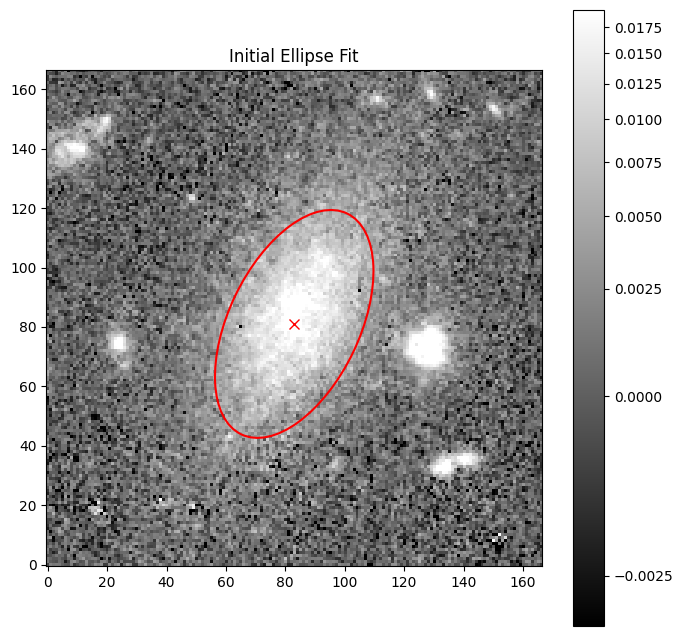

inside_non_fixed modification used


In [ ]:
ellipsefitter = 'v6'
print("\n3. Fitting initial ellipse model ...")
residual_basic, model_basic, geometry = MainFitEllipseModel(data, mask_cr=mask_cr, make_plots=make_plots, plot_plots=plot_plots, final=False, method=ellipsefitter, sma_rescale=sma_rescale)

print("\n4. Finding initial source mask ...")
source_mask = maskBackgroundSources(residual_basic, mask_cr=mask_cr, make_plots=make_plots, plot_plots=plot_plots, maxarea=maxarea_sourcemask, r=5)

print("\n5. Fitting final ellipse model ...")
residual_final, model_final, geometry = MainFitEllipseModel(data, mask_cr=source_mask, geometry=geometry, make_plots=make_plots, plot_plots=plot_plots, final=True, image_path=image_path,method=ellipsefitter, sma_rescale=sma_rescale)



6. Finding final source mask ...


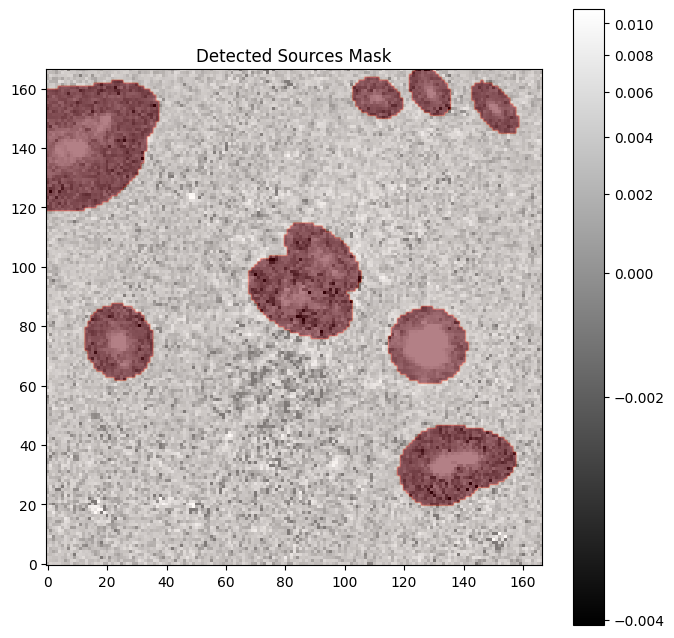


7. Creating required variables ...


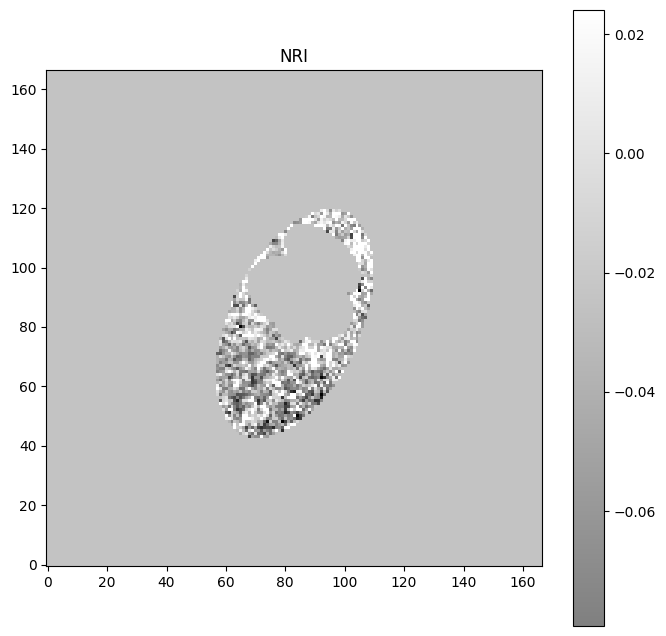


8 Calculate power spectra  ...


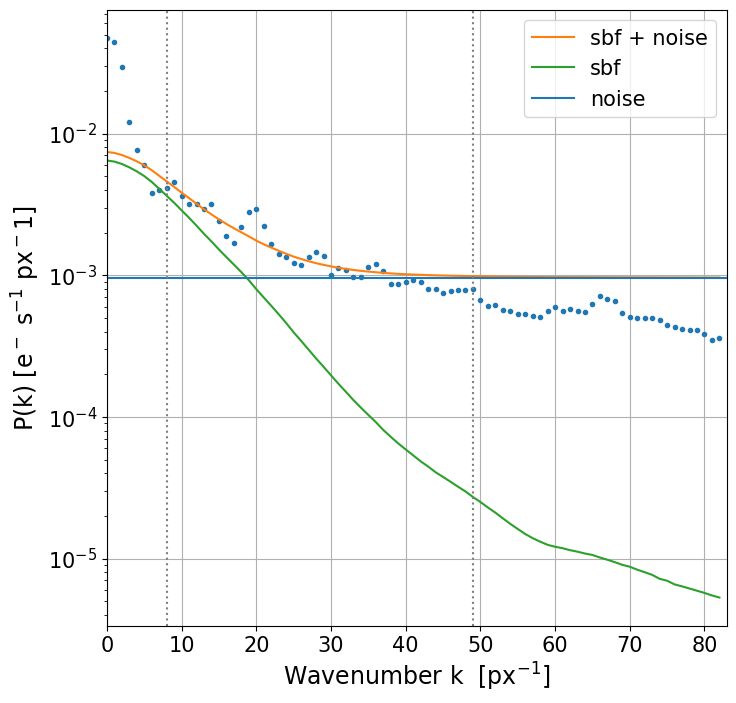


9. Calculate sbf magnitude
0.008539638904295929 29.071401232290146 -7.763176836306229e-05 41.22095059115592 23.9


In [17]:
print("\n6. Finding final source mask ...")
source_mask_final = maskBackgroundSources(residual_final, mask_cr=mask_cr, make_plots=make_plots, plot_plots=plot_plots, maxarea=maxarea_sourcemask, image_path=image_path, final=True, original_image=data, r=8)

print("\n7. Creating required variables ...")
mask_model, mask_combined, nri = createRequiredVariables(data, model_final, source_mask_final, psf, total_bckgr, geometry, make_plots=make_plots, plot_plots=plot_plots, image_path=image_path)

print("\n8 Calculate power spectra  ...")
image_ps, expected_ps, sbf, noise = calculateSBF(nri, mask_combined, psf,
                                                   norm_type = "MaskedPixels",
                                                   fit_range_i=0.1, fit_range_f=0.6,  
                                                   make_plots=make_plots,plot_plots=plot_plots,
                                                   image_path=image_path)
plt.close('all')
print("\n9. Calculate sbf magnitude")
sbfmag = appSBFmagnitude(sbf, mzp)

if file_path != None:
    np.savetxt(file_path + "/combined_final_mask", mask_combined)
    np.savetxt(file_path + "/color_final_mask", mask_model)
    np.savetxt(file_path + "/final_model", model_final)
    geometry_params = np.array((geometry.x0, geometry.y0, geometry.sma, geometry.eps, geometry.pa))
    np.savetxt(file_path + "/geometry", geometry_params)

print(sbf, sbfmag, total_bckgr, geometry.sma, mzp)

In [18]:
print(f"{'sbf':>10} {'sbfmag':>10} {'total_bckgr':>15} "
      f"{'sma':>10} {'mzp':>10} {'noise':>10} {'s_n':>10}")

print(f"{sbf:10.4f} {sbfmag:10.4f} {total_bckgr:15.4f} "
      f"{geometry.sma:10.4f} {mzp:10.4f} {noise:10.4f} {sbf/noise:10.4f}")


       sbf     sbfmag     total_bckgr        sma        mzp      noise        s_n
    0.0085    29.0714         -0.0001    41.2210    23.9000     0.0010     8.9192
